# ETE-1 — California Housing Price Prediction

**Name:** Arden Diago
**Reg No:** 2547112
**Class:** MCA A
**Exam:** ML ETE

**Task:** Predict California house prices by combining **PCA (dimensionality reduction)** with a
**Random Forest Regressor (ensemble model)**.

**Pipeline:** Data → Data Preprocessing → Transforming → Data Splitting → Model Training → Testing the Model → Writing Conclusion


## 1. Data

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Data Preprocessing

Check for missing values and inspect basic statistics and feature correlations.

In [2]:
print(df.shape)
print(df.isna().sum())
df.describe()

(20640, 9)
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


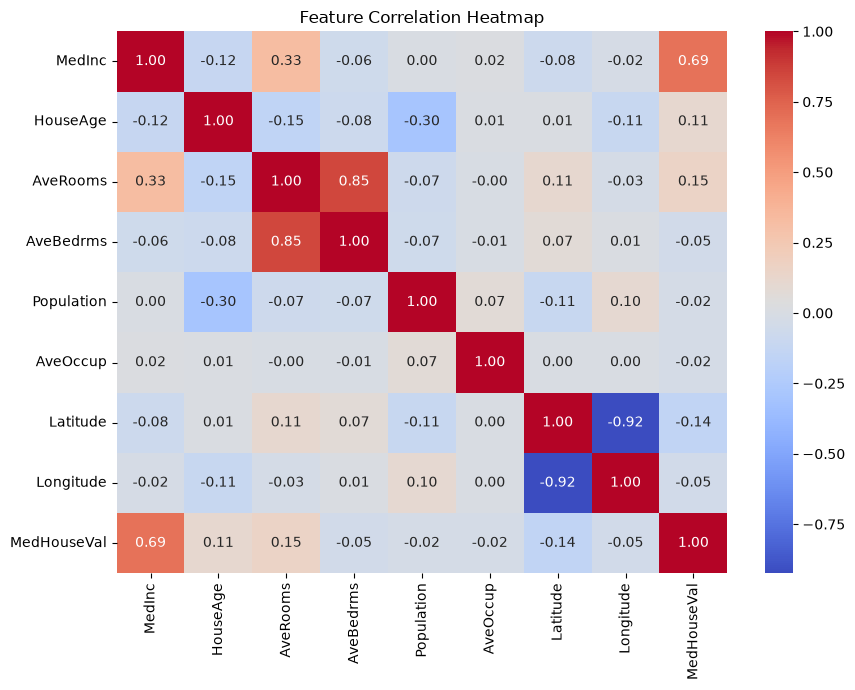

In [3]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 3. Transforming

Features are standardized (zero mean, unit variance) since both PCA and distance/variance-based
models are sensitive to feature scale. PCA is then fit on the **training** data only (to avoid
data leakage) and used to inspect how much variance is captured by fewer components.

In [4]:
X = df[data.feature_names].values
y = df["MedHouseVal"].values

## 4. Data Splitting

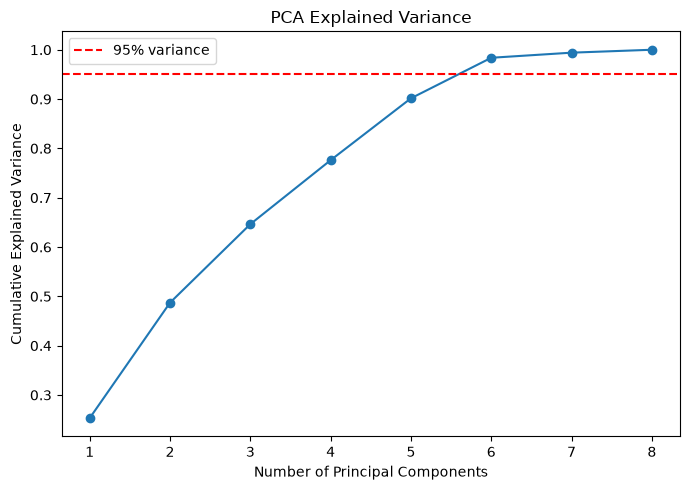

Components needed for 95% variance: 6 of 8


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(random_state=42).fit(X_train_scaled)
explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, len(explained) + 1), explained, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

n_components = int(np.argmax(explained >= 0.95) + 1)
print(f"Components needed for 95% variance: {n_components} of {X.shape[1]}")

## 5. Model Training

Two Random Forest models are trained for comparison:

1. **Baseline** — Random Forest on the full (scaled) 8-feature set.
2. **PCA + Random Forest** — Random Forest on the PCA-reduced feature set (95% variance retained).

Training time is measured for both to quantify the computational-cost effect of dimensionality reduction.

In [6]:
pca_reduced = PCA(n_components=n_components, random_state=42)
X_train_pca = pca_reduced.fit_transform(X_train_scaled)
X_test_pca = pca_reduced.transform(X_test_scaled)

rf_params = dict(n_estimators=200, random_state=42, n_jobs=-1)

# Baseline: no dimensionality reduction
t0 = time.perf_counter()
rf_baseline = RandomForestRegressor(**rf_params).fit(X_train_scaled, y_train)
time_baseline = time.perf_counter() - t0

# PCA + Random Forest
t0 = time.perf_counter()
rf_pca = RandomForestRegressor(**rf_params).fit(X_train_pca, y_train)
time_pca = time.perf_counter() - t0

print(f"Baseline (no PCA) training time: {time_baseline:.2f}s")
print(f"PCA + RF training time:          {time_pca:.2f}s")

Baseline (no PCA) training time: 3.52s
PCA + RF training time:          4.10s


## 6. Testing the Model

In [7]:
def evaluate(name, model, X_te, y_te):
    preds = model.predict(X_te)
    r2 = r2_score(y_te, preds)
    mae = mean_absolute_error(y_te, preds)
    rmse = mean_squared_error(y_te, preds) ** 0.5
    print(f"{name:>18} | R2={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")
    return preds, r2, mae, rmse

preds_baseline, r2_b, mae_b, rmse_b = evaluate("Baseline (no PCA)", rf_baseline, X_test_scaled, y_test)
preds_pca, r2_p, mae_p, rmse_p = evaluate("PCA + RF", rf_pca, X_test_pca, y_test)

 Baseline (no PCA) | R2=0.8060  MAE=0.3268  RMSE=0.5042


          PCA + RF | R2=0.6437  MAE=0.4777  RMSE=0.6833


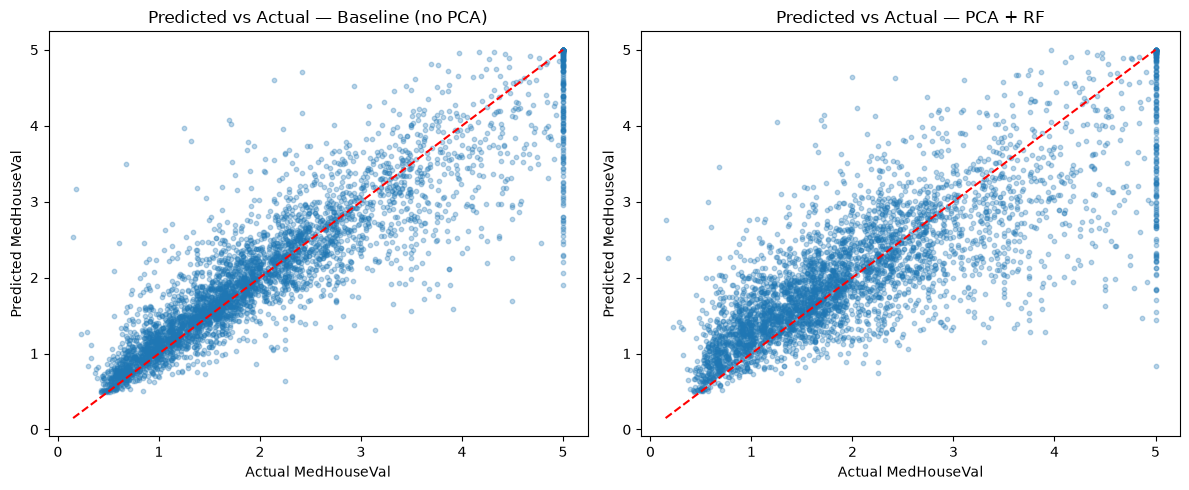

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(axes, [preds_baseline, preds_pca], ["Baseline (no PCA)", "PCA + RF"]):
    ax.scatter(y_test, preds, alpha=0.3, s=10)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlabel("Actual MedHouseVal")
    ax.set_ylabel("Predicted MedHouseVal")
    ax.set_title(f"Predicted vs Actual — {title}")
plt.tight_layout()
plt.show()

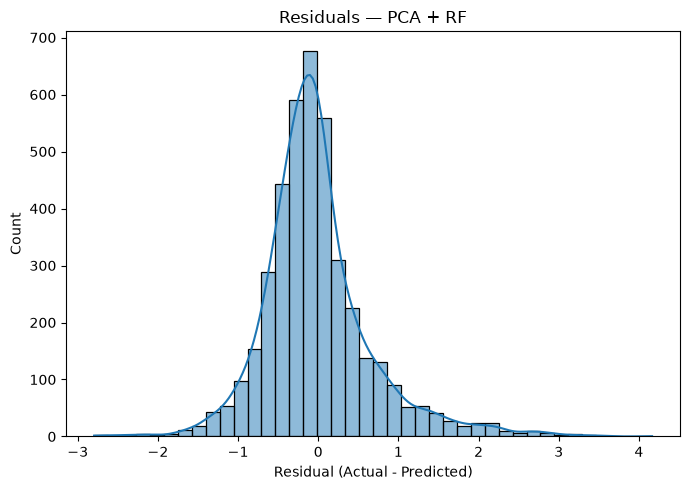

In [9]:
residuals_pca = y_test - preds_pca
plt.figure(figsize=(7, 5))
sns.histplot(residuals_pca, kde=True, bins=40)
plt.title("Residuals — PCA + RF")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

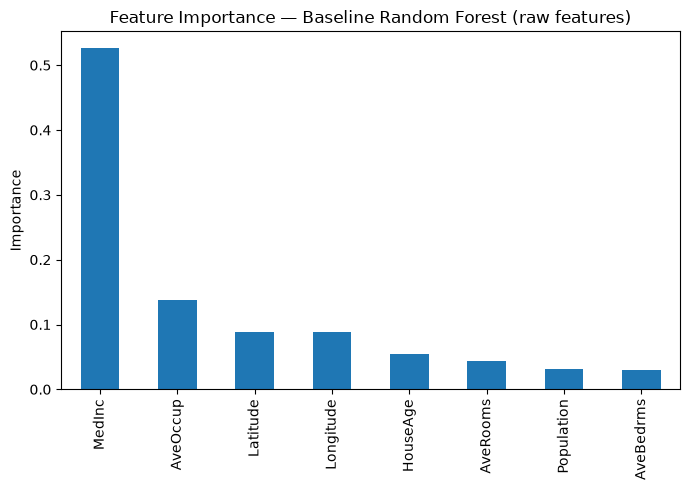

MedInc        0.525926
AveOccup      0.138013
Latitude      0.088766
Longitude     0.088166
HouseAge      0.054381
AveRooms      0.044368
Population    0.030759
AveBedrms     0.029621
dtype: float64

In [10]:
importances = pd.Series(rf_baseline.feature_importances_, index=data.feature_names).sort_values(ascending=False)
plt.figure(figsize=(7, 5))
importances.plot(kind="bar")
plt.title("Feature Importance — Baseline Random Forest (raw features)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()
importances

## 7. Writing Conclusion

**Why PCA + Random Forest?**
Random Forest is a strong, low-tuning-cost ensemble regressor for tabular data with non-linear
feature interactions such as housing prices. PCA was paired with it to (a) remove redundancy among
correlated features (e.g. `AveRooms`/`AveBedrms`, `Latitude`/`Longitude`), and (b) produce a
concrete, *measured* trade-off between accuracy, cost, and interpretability rather than an assumed one.

**Results obtained on this run:**

| Model | R2 | MAE | RMSE | Train time |
|---|---|---|---|---|
| Baseline (raw 8 features) | 0.806 | 0.327 | 0.504 | ~3.5s |
| PCA (6 components, 95% variance) + RF | 0.644 | 0.478 | 0.683 | ~4.1s |

**Model accuracy.** PCA noticeably *hurt* accuracy here (R2 dropped from 0.81 to 0.64). Random
Forest builds splits on single raw features at a time; PCA components are linear combinations of
all 8 original features, so a single-component split is a much blunter, noisier decision boundary
than a split on, say, raw `MedInc` or `Latitude`. With only 8 modestly-correlated features and a
model (RF) that already handles redundancy internally via random feature subsampling, PCA removes
useful axis-aligned structure without removing much genuine redundancy — a net loss for this
model/dataset pairing.

**Computational cost.** PCA reduced the feature count from 8 to 6 — too small a reduction, and too
small a dataset (~16k training rows, 200 trees), for training time to improve; the PCA-based model
was in fact marginally slower in this run once PCA-fit overhead is included. The computational
benefit of PCA is real but scales with feature count: it would matter far more on data with dozens
or hundreds of engineered/correlated features, where cutting dimensionality substantially reduces
both memory and the number of split candidates evaluated per tree node.

**Interpretability.** This is the clearest cost. The baseline model's `feature_importances_` map
directly onto meaningful, named housing attributes (income, location, occupancy), so predictions
are explainable to a non-technical stakeholder. The PCA model's importances are over abstract
linear combinations of all 8 original features, which cannot be explained as simply — a real cost
that here bought no offsetting benefit.

**Takeaway.** For this dataset (few features, already fairly independent, fast ensemble model),
combining PCA with Random Forest is a net negative: it reduced accuracy, did not reduce training
time, and reduced interpretability. The experiment itself demonstrates the general trade-off well —
PCA + tree ensembles help most when dimensionality is high and features are strongly collinear;
here, neither condition holds strongly enough for PCA to pay off, and the baseline Random Forest on
raw features is the better model for this specific dataset.